# An Intuition Builder for Regression Diagnostic Plots

Fitting a regression model is easy. Knowing whether you can *trust* it is the harder skill.

Diagnostic plots are some of the best and most widely accepted tools to build this trust. However, over the years I have noticed that instructors often gloss over these plots, as if the audience has the same intuitive understanding they do.

I developed this notebook to walk you through the plots while allowing you to interact with them, so that ***YOU* build the intuition!**

This notebook covers the **standard four-panel diagnostic set** (the same four plots R produces by
default from `plot(lm_model)`), plus a fifth check for the independence assumption that the standard
panel doesn't address:

1. **Residuals vs. Fitted** - checks linearity and homoscedasticity (constant variance)
2. **Q-Q Plot** - checks normality of residuals
3. **Scale-Location** - a dedicated, more sensitive view of homoscedasticity
4. **Residuals vs. Leverage (with Cook's distance)** - finds influential observations
5. **Residuals vs. order / ACF** - checks independence (relevant for ordered or time-series data)

For each one, we show what an **ideal** plot looks like next to plots showing **specific problems**,
so the shapes become recognizable at a glance rather than something you have to consciously reason
through every time.

**A note on what these plots do and don't tell you:** the first three check *model assumptions*.
The fourth plot is different, as it checks whether any individual data point is disproportionately
influencing your results. Both matter, but they're distinct questions, and conflating them is a
common source of confusion.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

np.random.seed(42)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 10

## 1. Residuals vs. Fitted Values

After fitting a model, plot the **residuals** (actual - predicted) on the y-axis against the
**fitted values** (predicted values) on the x-axis.

**What you're looking for:** a random, formless scatter of points around the horizontal line at
zero, with no pattern in the spread and no curve. If you see structure, that structure is telling
you something specific about which assumption is broken.

We'll simulate three datasets below: one that satisfies OLS assumptions cleanly, one with
**heteroscedasticity** (non-constant variance), and one with **non-linearity** (wrong functional
form). Same sample size and base noise scale throughout, so the *shape* of the residual plot is the
only thing that differs.


In [7]:
def fit_model(X, y):
    """Fit OLS and return the fitted model object."""
    X_with_const = sm.add_constant(X)
    return sm.OLS(y, X_with_const).fit()

n = 200
x = np.linspace(0, 10, n)

# Case 1: Ideal Example
y_ideal = 3 + 2 * x + np.random.normal(0, 3, n)
model_ideal = fit_model(x, y_ideal)

# Case 2: Heteroscedasticity (variance grows with x)
y_hetero = 3 + 2 * x + np.random.normal(0, 0.3 + 0.35 * x, n)
model_hetero = fit_model(x, y_hetero)

# Case 3: Non-linearity (true relationship is quadratic, model is linear)
y_nonlin = 3 + 1.2 * x + .9 * (x - 5) ** 2 + np.random.normal(0, 3, n)
model_nonlin = fit_model(x, y_nonlin)

Before we look at the residual plots, let's first build a foundation by understanding where they come from.

We will do so by observing a more familiar plot: predicted versus actuals plots.

Below we have predicted versus actuals plots for each of the three simulated datasets: the ideal linear set, the heteroscedastic set, and the non-linear set.

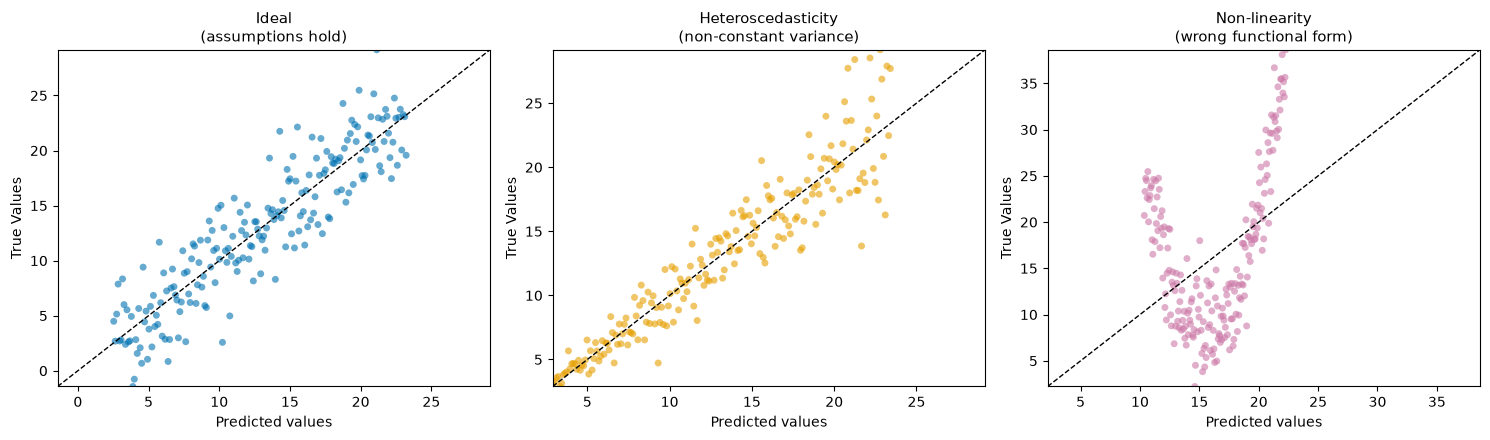

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

panels_1 = [
    (axes[0], model_ideal, y_ideal, "Ideal\n(assumptions hold)", "#0072B2"),
    (axes[1], model_hetero, y_hetero, "Heteroscedasticity\n(non-constant variance)", "#E69F00"),
    (axes[2], model_nonlin, y_nonlin, "Non-linearity\n(wrong functional form)", "#CC79A7"),
]

for ax, model, y_true, title, color in panels_1:
    ax.scatter(model.fittedvalues, y_true, alpha=0.6, s=25, color=color, edgecolor="none")
    lims = [min(model.fittedvalues.min(), y_true.min()),max(model.fittedvalues.max(), y_true.max())]
    ax.plot(lims, lims, color="black", linewidth=1, linestyle="--")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    #ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel("Predicted values")
    ax.set_ylabel("True Values")
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.show()

In the ideal panel, points hug the diagonal with no systematic drift. In the heteroscedastic panel, points sit close to the diagonal at low predicted values but scatter further from it as predicted values grow. In the non-linear panel, points bow away from the diagonal in the middle of the range and pull back toward it at the edges.

Each point's vertical distance from the dashed diagonal above is exactly its residual — how far the actual value sits from the predicted value. Below, we plot that distance directly: the horizontal axis stays the same (still fitted values), but the vertical axis now shows actual minus predicted instead of actual. The diagonal collapses into a flat line at zero, and everything else about each point's position carries over.

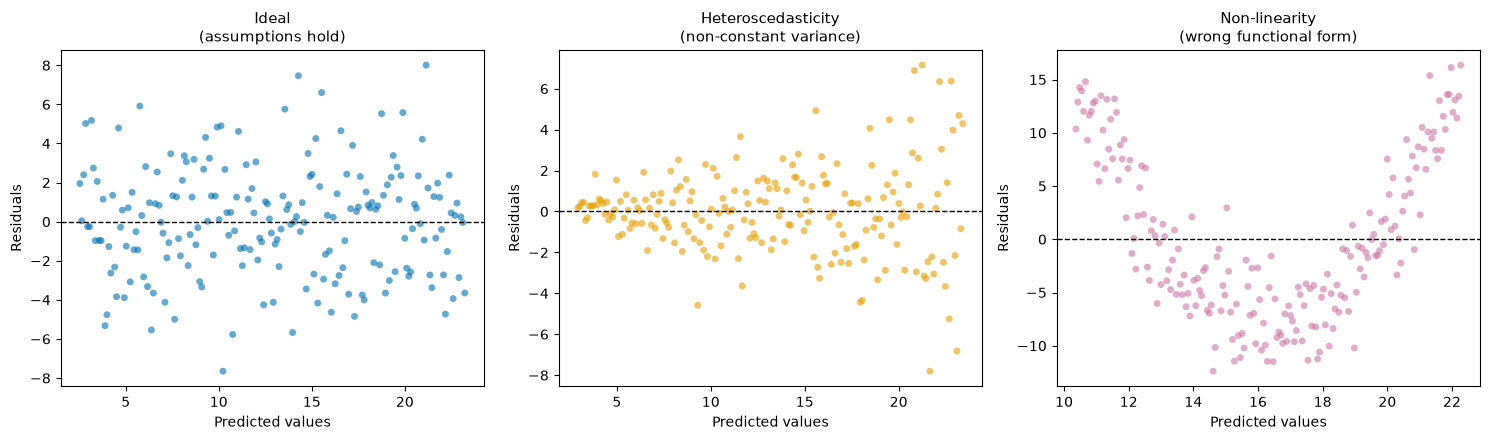

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

panels = [
    (axes[0], model_ideal, "Ideal\n(assumptions hold)", "#0072B2"),
    (axes[1], model_hetero, "Heteroscedasticity\n(non-constant variance)", "#E69F00"),
    (axes[2], model_nonlin, "Non-linearity\n(wrong functional form)", "#CC79A7"),
]

for ax, model, title, color in panels:
    ax.scatter(model.fittedvalues, model.resid, alpha=0.6, s=25, color=color, edgecolor="none")
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set_xlabel("Predicted values")
    ax.set_ylabel("Residuals")
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.show()


**Reading each panel:**

- **Ideal:** points scatter randomly above and below the zero line, with no widening and no curve. Homoscedasticity and linearity both hold.

- **Heteroscedasticity:** the *shape* is a fan. Residuals stay tight near low fitted values and spread out wider as fitted values increase. The mean of the residuals is still roughly zero everywhere (so it's *not* a linearity problem), but the **spread is not constant**, and that's the giveaway. 
Practical consequence: your standard errors (and therefore p-values and confidence intervals) become unreliable, even though the coefficient estimates themselves stay unbiased.

- **Non-linearity:** the residuals trace a visible **curve**, negative at the edges and positive in the middle (or vice versa). This means the model is systematically over- or under-predicting depending on where you are in the range of x, because the true relationship isn't a straight line. Fix: add a polynomial term, transform a variable, or reconsider the functional form.

**The distinction worth internalizing:** both patterns show up in the *same type* of plot, so it's easy to collapse "there's some pattern here" into one generic red flag. They're not the same problem, and they don't have the same fix. Heteroscedasticity is about the **spread and width** changing. Non-linearity is about the **center** of the residuals tracing a shape instead of sitting flat at zero.

## 2. Q-Q Plot (Normality Check)
placeholder

## 3. Scale-Location Plot
placeholder

## 4. Residuals vs. Leverage (and Cook's Distance)
placeholder

## 5. Independence: Residuals vs. Order (and the ACF)
placeholder